In [6]:
import pandas as pd
import random
import itertools
        

In [7]:
df = pd.read_csv('kombinasi_menu.csv')
df.head()

,Id_kombinasi,Makan_pagi,Makan_siang,Makan_malam,Snack_1,Snack_2,Total_natrium
0,1,Kering tempe,Tumis buncis wortel bintik,Tuna sambal woku,Susu,Buah delima,681.0
1,2,Rawon,Mie ayam,Bubur manado,Sari buah tropika,Buah delima,701.0
2,3,Coto makasar,Tumis buncis wortel bintik,Makaroni bumbu merah,Sup buah serut,Kue sus,687.3
3,4,Nasi pecel,Sate kambing,Sambal udang,Jus wortel tomat,Semangka,460.0
4,5,Teri basah goreng renyah,Bakmi,Urab,Apel,Kue nagasari,512.0


In [8]:
def label_derajat(total_natrium):
    if total_natrium <= 400:
        return "Derajat 3"
    elif total_natrium <= 800:
        return "Derajat 2"
    elif total_natrium <= 1200:
        return "Derajat 1"
    else:
        return "Di luar kategori"

In [9]:
df['Label Derajat'] = df['Total_natrium'].apply(label_derajat)

In [10]:
print("Distribusi label:")
print(df['Label Derajat'].value_counts())

Distribusi label:
Label Derajat
Derajat 1           373
Derajat 2           342
Di luar kategori    225
Derajat 3            60
Name: count, dtype: int64


In [11]:
import pandas as pd
import random

In [12]:
df = pd.read_csv("data_makanan.csv")
df.head()

,nama_makanan,kategori,natrium_(mg)
0,Nasi goreng ayam,makan_pagi,302.0
1,Nasi goreng,makan_pagi,415.0
2,Nasi goreng udang,makan_pagi,467.0
3,Nasi goreng spesial,makan_pagi,703.0
4,Bubur nasi,makan_pagi,126.0


In [13]:
df = pd.read_csv("data_makanan.csv")

# 2. Rapikan nama kategori (hilangkan spasi)
df['kategori'] = df['kategori'].str.strip().str.lower()

# 3. Bagi berdasarkan kategori
makan_pagi = df[df['kategori'] == 'makan_pagi']
makan_siang = df[df['kategori'] == 'makan_siang']
makan_malam = df[df['kategori'] == 'makan_malam']
snack_1 = df[df['kategori'] == 'snack_1']
snack_2 = df[df['kategori'] == 'snack_2']

# 4. Fungsi menentukan derajat berdasarkan total natrium
def derajat_total(natrium_total):
    if 1000 <= natrium_total <= 1200:
        return 1
    elif 600 <= natrium_total <= 800:
        return 2
    elif 200 <= natrium_total <= 400:
        return 3
    else:
        return 0  # di luar rentang derajat

# 5. Fungsi membuat kombinasi acak menu harian dan memberi label derajat
def generate_random_menus(df_pagi, df_siang, df_malam, df_snack1, df_snack2, target_per_derajat=300, max_iter=200000):
    hasil = {1: [], 2: [], 3: []}
    iter_count = 0

    while any(len(hasil[d]) < target_per_derajat for d in [1,2,3]) and iter_count < max_iter:
        iter_count += 1

        try:
            combo = (
                df_pagi.sample(1).iloc[0],
                df_siang.sample(1).iloc[0],
                df_malam.sample(1).iloc[0],
                df_snack1.sample(1).iloc[0],
                df_snack2.sample(1).iloc[0]
            )

            total_natrium = sum([item['natrium_(mg)'] for item in combo])
            derajat = derajat_total(total_natrium)

            if derajat != 0 and len(hasil[derajat]) < target_per_derajat:
                hasil[derajat].append({
                    'makan_pagi': combo[0]['nama_makanan'],
                    'makan_siang': combo[1]['nama_makanan'],
                    'makan_malam': combo[2]['nama_makanan'],
                    'snack_1': combo[3]['nama_makanan'],
                    'snack_2': combo[4]['nama_makanan'],
                    'total_natrium': total_natrium,
                    'derajat': derajat
                })
        except:
            continue

    # Gabungkan semua kombinasi jadi satu DataFrame
    all_data = []
    for d in [1, 2, 3]:
        all_data.extend(hasil[d])

    df_hasil = pd.DataFrame(all_data)
    return df_hasil

# 6. Jalankan fungsi dan simpan hasilnya
df_final = generate_random_menus(makan_pagi, makan_siang, makan_malam, snack_1, snack_2, target_per_derajat=300)

# 7. Lihat hasil
print(df_final['derajat'].value_counts())
print(df_final.head())

derajat
1    300
2    300
3    300
Name: count, dtype: int64
            makan_pagi              makan_siang             makan_malam  \
0  Ikan tongkol goreng                 Mie ayam            Bubur manado   
1         Belut goreng            Sup nasi ayam  Ikan bakar bumbu kecap   
2           Pepes tahu              Beef burger            Tempe pesmol   
3         Telur ceplok                  Spageti             Ayam kecap    
4    Tumis daun pepaya  Ikan tuna sambal goreng               Opor ayam   

       snack_1        snack_2  total_natrium  derajat  
0        Cilok        Markisa         1014.0        1  
1     Kue apem   Risol bihun          1024.5        1  
2  Putu mayang  Tahu sumedang         1099.5        1  
3      Pisang      Kue kacang         1094.0        1  
4    Talam ubi     Bolu kukus         1024.3        1  


In [14]:
# 8. Simpan ke file jika perlu
df_final.to_csv('menu_harian.csv', index=False)

In [15]:
df = pd.read_csv('menu_harian.csv')
df.head()

,makan_pagi,makan_siang,makan_malam,snack_1,snack_2,total_natrium,derajat
0,Ikan tongkol goreng,Mie ayam,Bubur manado,Cilok,Markisa,1014.0,1
1,Belut goreng,Sup nasi ayam,Ikan bakar bumbu kecap,Kue apem,Risol bihun,1024.5,1
2,Pepes tahu,Beef burger,Tempe pesmol,Putu mayang,Tahu sumedang,1099.5,1
3,Telur ceplok,Spageti,Ayam kecap,Pisang,Kue kacang,1094.0,1
4,Tumis daun pepaya,Ikan tuna sambal goreng,Opor ayam,Talam ubi,Bolu kukus,1024.3,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   makan_pagi     900 non-null    object 
 1   makan_siang    900 non-null    object 
 2   makan_malam    900 non-null    object 
 3   snack_1        900 non-null    object 
 4   snack_2        900 non-null    object 
 5   total_natrium  900 non-null    float64
 6   derajat        900 non-null    int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 49.3+ KB


In [17]:
print("Distribusi label:")
print(df['derajat'].value_counts())

Distribusi label:
derajat
1    300
2    300
3    300
Name: count, dtype: int64


In [18]:
import pandas as pd

In [19]:
df_natrium = pd.read_csv('data_makanan.csv')

In [20]:
df_kombinasi = pd.read_csv('menu_harian.csv')


In [21]:
# Bersihkan nama makanan di data natrium
df_natrium['nama_makanan'] = df_natrium['nama_makanan'].str.strip().str.lower()

In [22]:
# Bersihkan semua kolom makanan di kombinasi
for kol in ['makan_pagi', 'makan_siang', 'makan_malam', 'snack_1', 'snack_2']:
    df_kombinasi[kol] = df_kombinasi[kol].str.strip().str.lower()


In [23]:
natrium_dict = df_natrium.set_index('nama_makanan')['natrium_(mg)'].to_dict()

In [24]:
for kolom in ['makan_pagi', 'makan_siang', 'makan_malam', 'snack_1', 'snack_2']:
    df_kombinasi[f'natrium_{kolom}'] = df_kombinasi[kolom].map(natrium_dict)

In [25]:
df_kombinasi['total_natrium'] = df_kombinasi[[f'natrium_{kolom}' for kolom in ['makan_pagi', 'makan_siang', 'makan_malam', 'snack_1', 'snack_2']]].sum(axis=1)

In [26]:
# Buat kolom derajat berdasarkan total natrium
def tentukan_derajat(natrium):
    if 1000 <= natrium <= 1200:
        return 1
    elif 600 <= natrium <= 800:
        return 2
    elif 200 <= natrium <= 400:
        return 3
    else:
        return 0  

In [27]:
df_kombinasi['derajat'] = df_kombinasi['total_natrium'].apply(tentukan_derajat)

In [28]:
# Simpan hasil
df_kombinasi.to_csv('data_kombinasi.csv', index=False)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

In [30]:
df = pd.read_csv('data_kombinasi_na.csv')
df.head()

,makan_pagi,makan_siang,makan_malam,snack_1,snack_2,total_natrium,derajat,natrium_makan_pagi,natrium_makan_siang,natrium_makan_malam,natrium_snack_1,natrium_snack_2
0,soto ayam,tumis bayam,sup kentang,puding coklat,es doger,1166.0,1,87.0,408.0,418.0,129.0,124
1,tumis kangkung,beef burger,tumis ikan tongkol,mentimun serut,martabak telur,1116.1,1,384.0,572.0,19.0,6.1,135
2,semur jengkol,ikan salmon panggang,kalio kikil,klepon,tape singkong,1132.0,1,60.0,467.0,519.0,79.0,7
3,usus ayam goreng,bakmi,rendang,jus wortel tomat,martabak telur,1078.0,1,411.0,329.0,184.0,19.0,135
4,soto ayam,ikan belanak goreng,lobstre panggang,sup buah serut,serabi,1067.3,1,87.0,220.0,630.0,33.3,97


In [31]:
df = df[df['derajat'] != 0]


In [32]:
print(df['derajat'].value_counts())

derajat
1    300
2    300
3    300
Name: count, dtype: int64


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   makan_pagi           900 non-null    object 
 1   makan_siang          900 non-null    object 
 2   makan_malam          900 non-null    object 
 3   snack_1              900 non-null    object 
 4   snack_2              900 non-null    object 
 5   total_natrium        900 non-null    float64
 6   derajat              900 non-null    int64  
 7   natrium_makan_pagi   900 non-null    float64
 8   natrium_makan_siang  900 non-null    float64
 9   natrium_makan_malam  900 non-null    float64
 10  natrium_snack_1      900 non-null    float64
 11  natrium_snack_2      900 non-null    int64  
dtypes: float64(5), int64(2), object(5)
memory usage: 84.5+ KB


In [34]:
print("Missing Values:")  
print(df.isnull().sum()) 

Missing Values:
makan_pagi             0
makan_siang            0
makan_malam            0
snack_1                0
snack_2                0
total_natrium          0
derajat                0
natrium_makan_pagi     0
natrium_makan_siang    0
natrium_makan_malam    0
natrium_snack_1        0
natrium_snack_2        0
dtype: int64


In [35]:
X = df[['natrium_makan_pagi', 'natrium_makan_siang', 'natrium_makan_malam', 'natrium_snack_1', 'natrium_snack_2']]  # fitur
y = df['derajat']

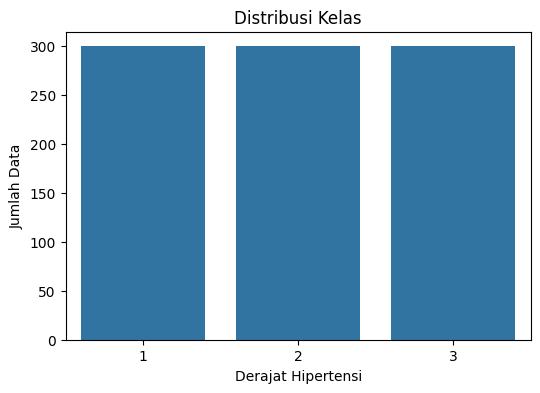

In [36]:
# --- 2. Cek Distribusi Data ---
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribusi Kelas")
plt.xlabel("Derajat Hipertensi")
plt.ylabel("Jumlah Data")
plt.show()

In [37]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [38]:
print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 630
Jumlah data testing: 270


In [39]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)





KNeighborsClassifier(n_neighbors=2)

In [40]:
# Simpan model dan scaler
joblib.dump(knn, 'model.pkl')


['model.pkl']

In [41]:
import joblib

knn = joblib.load('model.pkl')
print("Model loaded:", knn)
print("Apakah model sudah di-fit?:", hasattr(knn, "classes_"))

Model loaded: KNeighborsClassifier(n_neighbors=2)
Apakah model sudah di-fit?: True


In [42]:
# --- 6. Prediksi dan Evaluasi ---
y_pred = knn.predict(X_test)

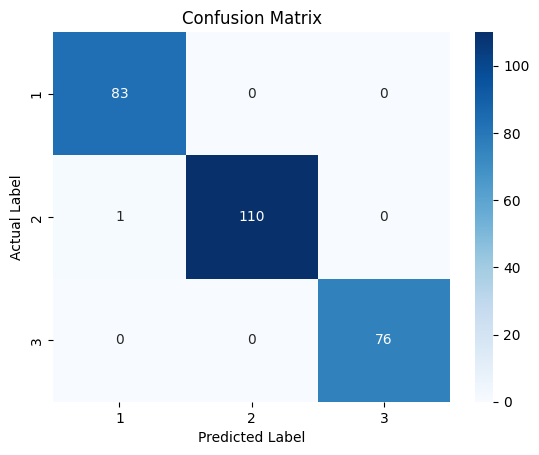

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Buat confusion matrix dengan label asli
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])

# Buat heatmap dengan label 1, 2, 3 di sumbu X dan Y
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 83   0   0]
 [  1 110   0]
 [  0   0  76]]


In [45]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, digits=4)
print(report)



              precision    recall  f1-score   support

           1     0.9881    1.0000    0.9940        83
           2     1.0000    0.9910    0.9955       111
           3     1.0000    1.0000    1.0000        76

    accuracy                         0.9963       270
   macro avg     0.9960    0.9970    0.9965       270
weighted avg     0.9963    0.9963    0.9963       270



In [46]:
# --- 7. Cross-Validation untuk Cek Nilai k Optimal ---
from sklearn.model_selection import StratifiedKFold

k_values = range(1, 21)
mean_accuracies = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')

    mean_accuracies.append(scores.mean())
    print(f"k={k}, Akurasi Rata-rata: {scores.mean():.4f}")

k=1, Akurasi Rata-rata: 0.9944
k=2, Akurasi Rata-rata: 0.9956
k=3, Akurasi Rata-rata: 0.9933
k=4, Akurasi Rata-rata: 0.9933
k=5, Akurasi Rata-rata: 0.9900
k=6, Akurasi Rata-rata: 0.9900
k=7, Akurasi Rata-rata: 0.9889
k=8, Akurasi Rata-rata: 0.9900
k=9, Akurasi Rata-rata: 0.9867
k=10, Akurasi Rata-rata: 0.9889
k=11, Akurasi Rata-rata: 0.9833
k=12, Akurasi Rata-rata: 0.9822
k=13, Akurasi Rata-rata: 0.9811
k=14, Akurasi Rata-rata: 0.9822
k=15, Akurasi Rata-rata: 0.9800
k=16, Akurasi Rata-rata: 0.9800
k=17, Akurasi Rata-rata: 0.9789
k=18, Akurasi Rata-rata: 0.9800
k=19, Akurasi Rata-rata: 0.9767
k=20, Akurasi Rata-rata: 0.9789


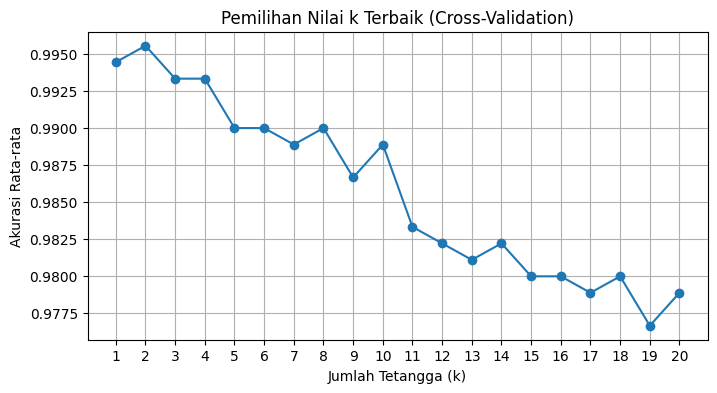

In [47]:
# --- 8. Visualisasi Nilai k vs Akurasi ---
plt.figure(figsize=(8, 4))
plt.plot(k_values, mean_accuracies, marker='o')
plt.title("Pemilihan Nilai k Terbaik (Cross-Validation)")
plt.xlabel("Jumlah Tetangga (k)")
plt.ylabel("Akurasi Rata-rata")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [48]:
# --- 9. Pilih k terbaik ---
optimal_k = k_values[np.argmax(mean_accuracies)]
print(f"\n✅ Nilai k terbaik adalah: {optimal_k:.0f} dengan akurasi rata-rata: {max(mean_accuracies):.4f}")


✅ Nilai k terbaik adalah: 2 dengan akurasi rata-rata: 0.9956
